##### Instructions #####
- Create a Python notebook to anwer all shown procedures, exercises and analysis in this section.
##### Resources #####
 - Download the following datasets: earthquakes-1.csv, fb_stock_prices_2018.csv 
##### Procedures #####
- 9.1 Introduction to Matplotlib <br>

In [3]:
pip install matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

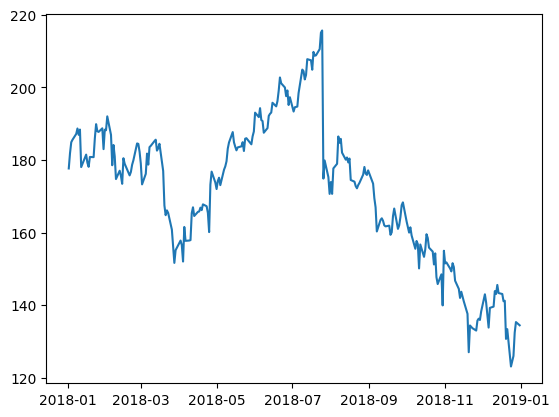

In [8]:
fb = pd.read_csv('fb_stock_prices_2018.csv', index_col='date', parse_dates=True)

plt.plot(fb.index, fb.open)
plt.show()

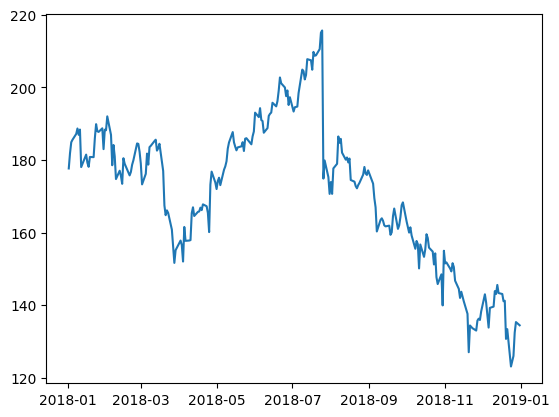

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
fb = pd.read_csv('fb_stock_prices_2018.csv', index_col='date', parse_dates=True)
plt.plot(fb.index, fb.open)

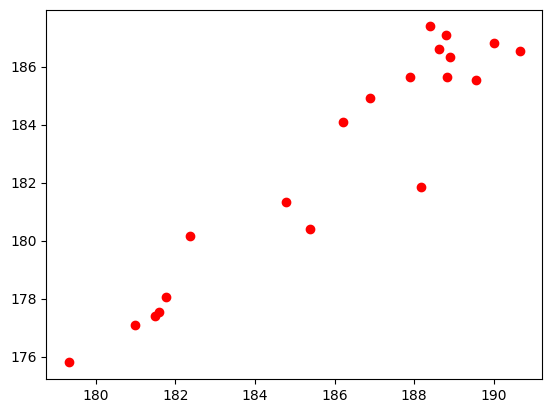

In [13]:
plt.plot('high', 'low', 'ro', data=fb.head(20))


(array([6.400e+01, 4.450e+02, 1.137e+03, 1.853e+03, 2.114e+03, 8.070e+02,
        2.800e+02, 9.200e+01, 9.000e+00, 2.000e+00]),
 array([-1.26 , -0.624,  0.012,  0.648,  1.284,  1.92 ,  2.556,  3.192,
         3.828,  4.464,  5.1  ]),
 <BarContainer object of 10 artists>)

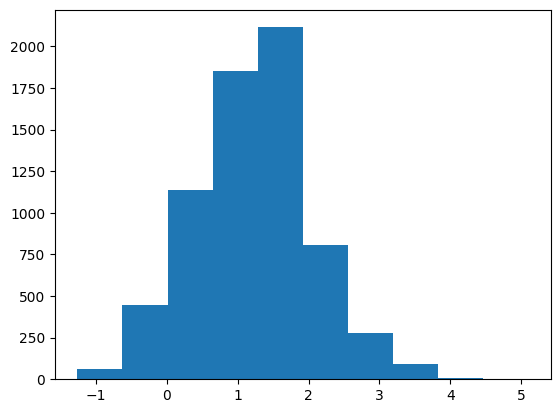

In [15]:
quakes = pd.read_csv('earthquakes-1.csv')
plt.hist(quakes.query('magType == "ml"').mag)

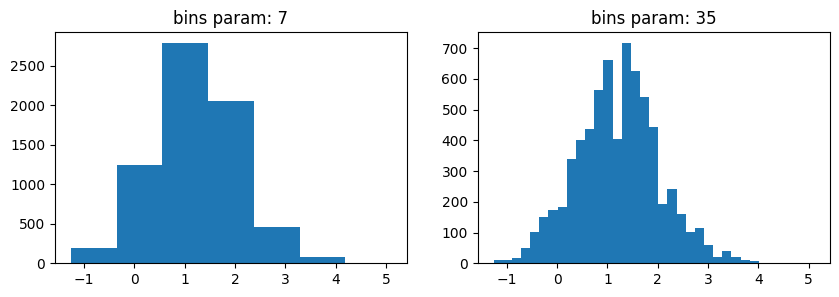

In [17]:
x = quakes.query('magType == "ml"').mag
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, bins in zip(axes, [7, 35]):
    ax.hist(x, bins=bins)
    ax.set_title(f'bins param: {bins}')

<Figure size 640x480 with 0 Axes>

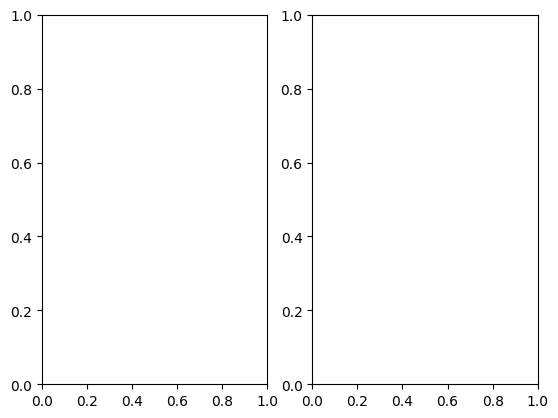

In [18]:
fig = plt.figure()
fig, axes = plt.subplots(1, 2)


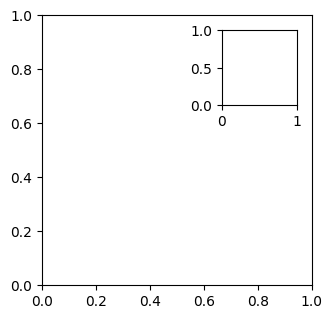

In [20]:
fig = plt.figure(figsize=(3, 3))
outside = fig.add_axes([0.1, 0.1, 0.9, 0.9])
inside = fig.add_axes([0.7, 0.7, 0.25, 0.25])

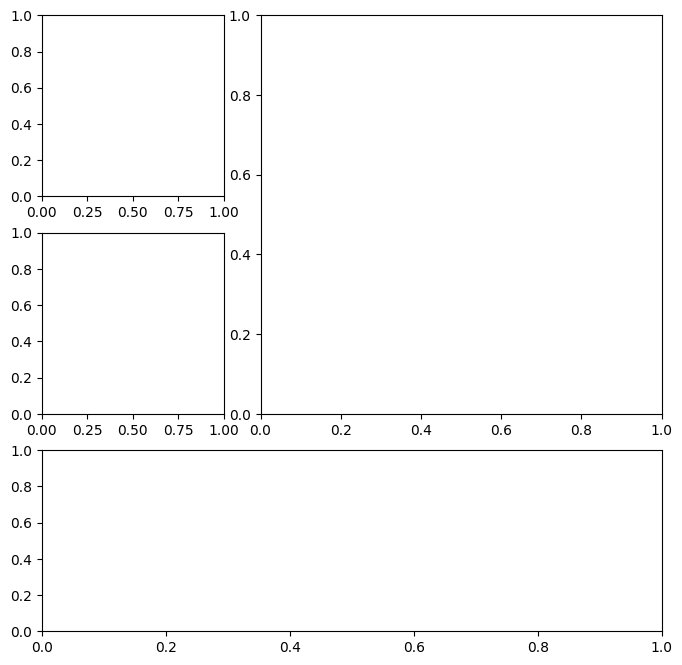

In [21]:
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(3, 3)
top_left = fig.add_subplot(gs[0, 0])
mid_left = fig.add_subplot(gs[1, 0])
top_right = fig.add_subplot(gs[:2, 1:])
bottom = fig.add_subplot(gs[2,:])

In [23]:
fig.savefig('empty.png')

In [24]:
plt.close('all')

In [26]:
fig = plt.figure(figsize=(10, 4))

<Figure size 1000x400 with 0 Axes>

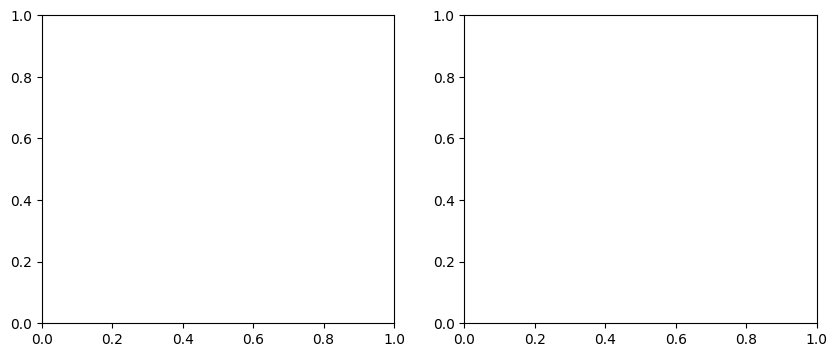

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

In [27]:
import random
import matplotlib as mpl
rcparams_list = list(mpl.rcParams.keys())
random.seed(20) # make this repeatable
random.shuffle(rcparams_list)
sorted(rcparams_list[:20])

['axes.edgecolor',
 'axes.titleweight',
 'boxplot.whiskerprops.linestyle',
 'date.autoformatter.day',
 'figure.constrained_layout.hspace',
 'figure.titlesize',
 'image.interpolation_stage',
 'keymap.copy',
 'legend.framealpha',
 'legend.handleheight',
 'lines.dash_joinstyle',
 'lines.markerfacecolor',
 'mathtext.default',
 'mathtext.fallback',
 'pdf.compression',
 'svg.fonttype',
 'text.usetex',
 'yaxis.labellocation',
 'ytick.major.size',
 'ytick.minor.visible']

In [28]:
mpl.rcParams['figure.figsize']

[6.4, 4.8]

In [29]:
mpl.rcParams['figure.figsize'] = (300, 10)
mpl.rcParams['figure.figsize']

[300.0, 10.0]

In [30]:
mpl.rcdefaults()
mpl.rcParams['figure.figsize']

[6.4, 4.8]

In [31]:
plt.rc('figure', figsize=(20, 20)) # change figsize default to (20, 20)
plt.rcdefaults() # reset the default

- 9.2 Plotting with Pandas <br>


In [33]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
fb = pd.read_csv(
'fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)

array([[<Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>,
        <Axes: xlabel='volume', ylabel='open'>],
       [<Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>,
        <Axes: xlabel='volume', ylabel='high'>],
       [<Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>,
        <Axes: xlabel='volume', ylabel='low'>],
       [<Axes: xlabel='open', ylabel='close'>,
        <Axes: xlabel='high', ylabel='close'>,
        <Axes: xlabel='low', ylabel='close'>,
        <Axes: xlabel='close', ylabel='close'>,
        <Axes: xlabel='volume', ylabel='close'>],
       [<Axes: xlabel='open', ylabel='volume'>,
        <Axes: xlabe

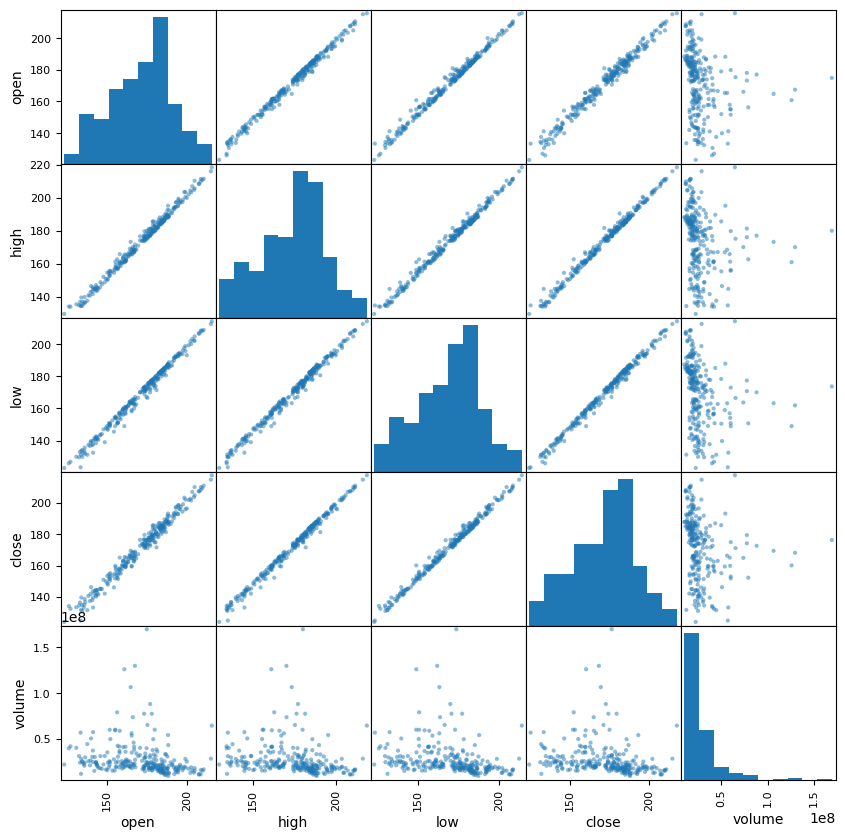

In [34]:
from pandas.plotting import scatter_matrix
scatter_matrix(fb, figsize=(10, 10))

In [ ]:
pip install scipy

ModuleNotFoundError: No module named 'scipy'

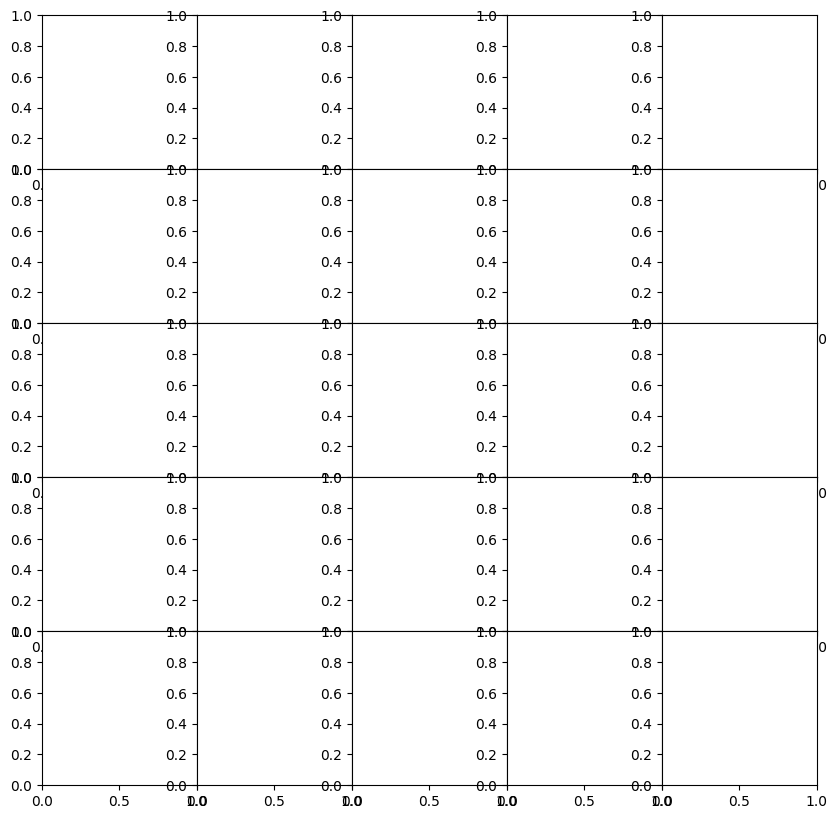

In [35]:
scatter_matrix(fb, figsize=(10, 10), diagonal='kde')

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

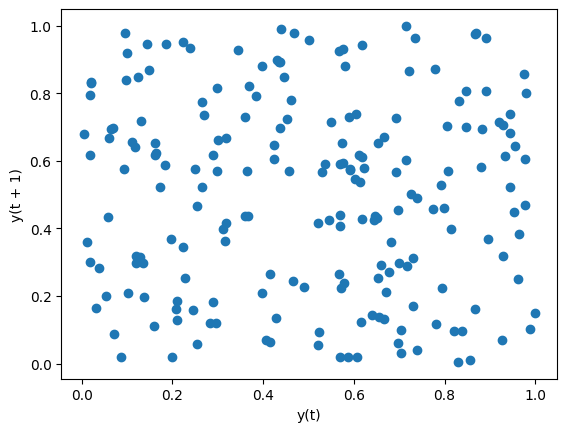

In [37]:
from pandas.plotting import lag_plot
np.random.seed(0) # make this repeatable
lag_plot(pd.Series(np.random.random(size=200)))

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

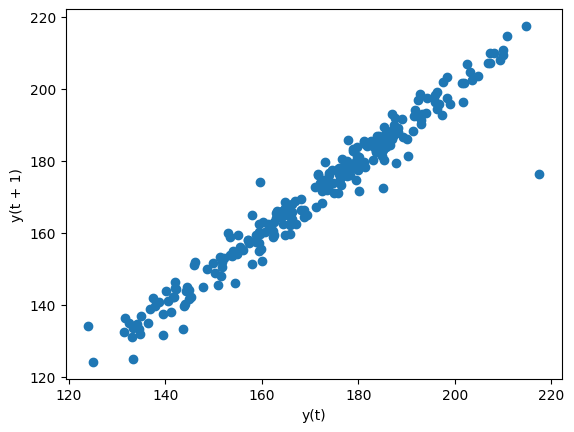

In [38]:
lag_plot(fb.close)

<Axes: xlabel='y(t)', ylabel='y(t + 5)'>

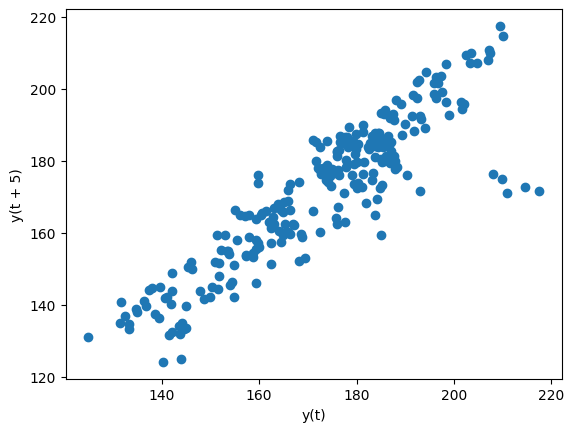

In [39]:
lag_plot(fb.close, lag=5)

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

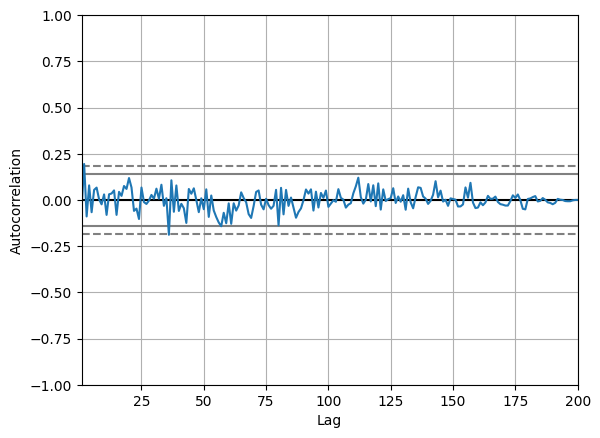

In [40]:
from pandas.plotting import autocorrelation_plot
np.random.seed(0) # make this repeatable
autocorrelation_plot(pd.Series(np.random.random(size=200)))

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

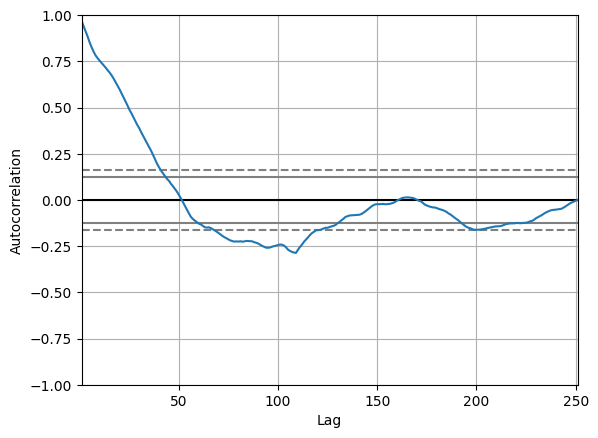

In [41]:
autocorrelation_plot(fb.close)

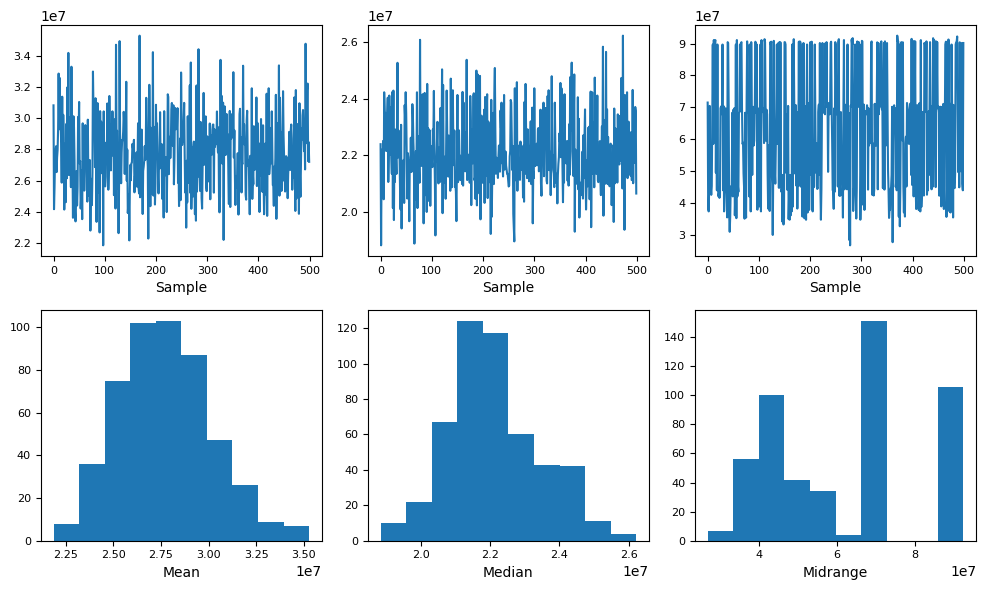

In [42]:
from pandas.plotting import bootstrap_plot
fig = bootstrap_plot(fb.volume, fig=plt.figure(figsize=(10, 6)))

- 9.3 Pandas Plotting Subpackage

##### Data Analysis: ##### 
- Provide comments on output from the procedures above.
##### Supplementary Activity: #####
- Using the CSV files provided and what we have laerned so far int his module complete the following exercises: <br>
1. Plot the rolling 20-day minimum of the Facebook closing price with the pandas plot() method. <br>

2. Create a histogram and KDE of the change from open to close in the price of Facebook stock.<br>
3. Using the earthquake data, create box plots for the magnitudes of each magType used in Indonesia. <br>

4. Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook. This should be a single
line. <br>

5. Using matplotlib and pandas, create two subplots side-by-side showing the effect that after-hours trading has had on Facebook's stock price: <br>

    - The first subplot will contain a line plot of the daily difference between that day's opening price and the prior day's closing price (be sure to review the Time series section of Aggregating Pandas DataFrames for an easy way to do this).<br>

    - The second subplot will be a bar plot showing the net effect this had monthly, using resample().<br>

    - Bonus #1: Color the bars according to whether they are gains in the stock price (green) or drops in the stock price (red).<br>

    - Bonus #2: Modify the x-axis of the bar plot to show the threeletter abbreviation for the month.<br>



##### Summary/ Conclusion: #####
- Provide a summary of your learnings and the conclusion for this activity.
